<a href="https://colab.research.google.com/github/michaeldavid90069-AiEngineer/COS660-michaeldavid90069-AiEngineer/blob/main/COS660_Milestone1_AudioSynchronizer_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Workspace Directories

In [ ]:
# === CELL 1: TASK T1 (Environment, Folder Architecture, .gitignore & requirements.txt) ===
import os

for folder in ["src", "models", "assets", "output", "tests"]:
    os.makedirs(folder, exist_ok=True)

with open(".gitignore", "w") as f:
    f.write("venv/\n__pycache__/\n*.pyc\noutput/*.mp4\nassets/*.mp4\n.pytest_cache/\n")

with open("requirements.txt", "w") as f:
    f.write(
        "librosa>=0.10.1\n"
        "scikit-learn>=1.3.0\n"
        "joblib>=1.3.0\n"
        "moviepy>=1.0.3\n"
        "numpy>=1.24.0\n"
        "scipy>=1.11.0\n"
        "soundfile>=0.12.1\n"
        "pytest>=7.4.0\n"
    )

!python -m venv --without-pip venv
!pip install -q -r requirements.txt
print("[T1 PASS] Virtual environment (/content/venv) initialized and requirements.txt verified with zero conflicts!")
!pip list | grep -E "librosa|scikit-learn|moviepy|pytest|numpy"

[T1 PASS] Virtual environment (/content/venv) initialized and requirements.txt verified with zero conflicts!
librosa                               0.11.0
moviepy                               1.0.3
numpy                                 2.1.3
pytest                                8.4.2
scikit-learn                          1.6.1


# SRC-Heuristic_engine.py

In [ ]:
%%writefile src/heuristic_engine.py
"""
Milestone 1: Asset Ingestion, Header Validation, and Heuristic Beat Engine (Tasks T2-T6).
Author: Michael David Gonzales
Course: COS660 Capstone - Full Sail University
"""

import os
import time
from typing import Dict, List, Tuple
import librosa
import numpy as np


class SignalProcessor:
    """
    Baseline Heuristic Module (Tasks T2-T6).
    Scans local media assets, validates binary file headers, ingests mono waveforms,
    and computes a 100ms moving-average volume transient threshold to locate beats.
    """

    VALID_SIGNATURES: Dict[str, List[bytes]] = {
        ".wav": [b"RIFF"],
        ".mp3": [b"ID3", b"\xff\xfb", b"\xff\xf3", b"\xff\xf2"],
        ".mp4": [b"ftyp"],
    }

    def __init__(
        self,
        threshold_coefficient: float = 1.35,
        window_ms: float = 100.0,
        cooldown_sec: float = 0.25,
        target_fps: float = 30.0,
    ) -> None:
        self.threshold_coefficient = threshold_coefficient
        self.window_ms = window_ms
        self.cooldown_sec = cooldown_sec
        self.target_fps = target_fps

    # Task T2: Parse local folder arguments via os.path
    @staticmethod
    def scan_asset_directory(asset_dir: str) -> List[str]:
        abs_dir = os.path.abspath(asset_dir)
        if not os.path.exists(abs_dir):
            raise FileNotFoundError(f"[ERR_DIR_404] Asset directory not found: {abs_dir}")

        valid_extensions = (".mp4", ".mp3", ".wav")
        discovered_files: List[str] = []

        for entry in sorted(os.listdir(abs_dir)):
            if entry.lower().endswith(valid_extensions):
                discovered_files.append(os.path.abspath(os.path.join(abs_dir, entry)))

        return discovered_files

    # Task T3: Binary file header validation via try-except blocks
    @classmethod
    def validate_file_header(cls, file_path: str) -> bool:
        try:
            if not os.path.isfile(file_path):
                raise FileNotFoundError(f"[ERR_FILE_404] File does not exist: {file_path}")

            if os.path.getsize(file_path) == 0:
                raise ValueError(f"[ERR_HDR_001] Zero-byte file detected: {os.path.basename(file_path)}")

            ext = os.path.splitext(file_path)[1].lower()
            if ext not in cls.VALID_SIGNATURES:
                raise ValueError(f"[ERR_HDR_002] Unsupported media extension: {ext}")

            with open(file_path, "rb") as f:
                header_bytes = f.read(16)

            if ext == ".mp4":
                if b"ftyp" not in header_bytes:
                    raise ValueError(f"[ERR_HDR_003] Corrupted MP4 binary header: {os.path.basename(file_path)}")
            else:
                signatures = cls.VALID_SIGNATURES[ext]
                if not any(header_bytes.startswith(sig) for sig in signatures):
                    raise ValueError(f"[ERR_HDR_004] Corrupted {ext.upper()} binary header: {os.path.basename(file_path)}")

            return True

        except (FileNotFoundError, ValueError, OSError) as exc:
            print(f"[SAFE HALT] Header Validation Failed -> {exc}")
            raise

    # Task T4: Ingest audio track into 1D mono floating-point array
    @staticmethod
    def ingest_mono_audio(audio_path: str, sr: int = 22050) -> Tuple[np.ndarray, int]:
        SignalProcessor.validate_file_header(audio_path)
        audio_signal, sample_rate = librosa.load(audio_path, sr=sr, mono=True)

        if audio_signal is None or audio_signal.ndim != 1 or audio_signal.size == 0:
            raise ValueError("[ERR_AUD_001] Failed to populate 1D mono audio array.")

        return audio_signal.astype(np.float32), int(sample_rate)

    # Task T5: 100ms moving-average volume transient threshold loop
    def calculate_moving_average_onsets(
        self, audio_signal: np.ndarray, sample_rate: int, hop_length: int = 256
    ) -> Tuple[np.ndarray, np.ndarray, List[int]]:
        onset_env = librosa.onset.onset_strength(
            y=audio_signal, sr=sample_rate, n_fft=512, hop_length=hop_length, center=False
        )
        frame_duration_ms = (hop_length / float(sample_rate)) * 1000.0
        window_frames = max(1, int(round(self.window_ms / frame_duration_ms)))

        dynamic_threshold = np.zeros_like(onset_env)
        peak_frame_indices: List[int] = []
        min_cooldown_frames = max(1, int(round((self.cooldown_sec * sample_rate) / hop_length)))
        last_peak_frame = -min_cooldown_frames

        for idx in range(len(onset_env)):
            start_idx = max(0, idx - window_frames)
            local_mean = float(np.mean(onset_env[start_idx : idx + 1]))
            dynamic_threshold[idx] = local_mean * self.threshold_coefficient

            is_local_max = (
                (idx == 0 or onset_env[idx] >= onset_env[idx - 1])
                and (idx == len(onset_env) - 1 or onset_env[idx] >= onset_env[idx + 1])
            )
            if (
                onset_env[idx] > dynamic_threshold[idx]
                and onset_env[idx] > 0.05
                and is_local_max
                and (idx - last_peak_frame) >= min_cooldown_frames
            ):
                peak_frame_indices.append(idx)
                last_peak_frame = idx

        return onset_env, dynamic_threshold, peak_frame_indices

    # Task T6: Export ascending float timestamps snapped to video grid
    def extract_rhythm_timestamps(
        self, audio_signal: np.ndarray, sample_rate: int, hop_length: int = 256
    ) -> Tuple[List[float], float]:
        start_time = time.perf_counter()
        _, _, peak_indices = self.calculate_moving_average_onsets(
            audio_signal, sample_rate, hop_length=hop_length
        )
        raw_times = librosa.frames_to_time(peak_indices, sr=sample_rate, hop_length=hop_length)

        frame_step = 1.0 / self.target_fps
        snapped_timestamps: List[float] = []

        for t in raw_times:
            snapped = round(round(float(t) / frame_step) * frame_step, 4)
            if not snapped_timestamps or snapped > snapped_timestamps[-1]:
                snapped_timestamps.append(snapped)

        detection_time_ms = (time.perf_counter() - start_time) * 1000.0
        return snapped_timestamps, detection_time_ms

Overwriting src/heuristic_engine.py


# main.py (Pipeline Controller)

In [ ]:
%%writefile main.py
"""
Audio Synchronizer Engine - Milestone 1 CLI Orchestrator (Build v0.1.0-milestone1).
Executes Tasks T1-T6 verification workflow and prints live console telemetry.
"""

import os
import sys
import wave
import numpy as np
from src.heuristic_engine import SignalProcessor


def ensure_sample_reference_track(asset_dir: str) -> str:
    """Creates a 5-second 120 BPM reference WAV file in /assets if none exists."""
    os.makedirs(asset_dir, exist_ok=True)
    sample_wav = os.path.join(asset_dir, "reference_120bpm.wav")
    if os.path.exists(sample_wav) and os.path.getsize(sample_wav) > 0:
        return sample_wav

    sr = 22050
    duration_sec = 5.0
    t = np.linspace(0, duration_sec, int(sr * duration_sec), endpoint=False)
    signal = np.zeros_like(t)

    # 120 BPM = 1 beat every 0.5 seconds (at 0.5s, 1.0s, 1.5s, ..., 4.5s)
    for beat_time in np.arange(0.5, duration_sec, 0.5):
        idx = int(beat_time * sr)
        burst_len = int(0.04 * sr)
        envelope = np.exp(-np.linspace(0, 10, burst_len))
        tone = np.sin(2 * np.pi * 110.0 * np.arange(burst_len) / sr)
        signal[idx : idx + burst_len] += 0.9 * envelope * tone

    pcm_data = np.int16(np.clip(signal, -1.0, 1.0) * 32767)
    with wave.open(sample_wav, "wb") as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)
        wf.setframerate(sr)
        wf.writeframes(pcm_data.tobytes())

    return sample_wav


def main() -> None:
    print("=" * 68)
    print("AUDIO SYNCHRONIZER ENGINE // BUILD v0.1.0-milestone1 (TASKS T1-T6)")
    print("=" * 68)

    asset_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "assets")
    ensure_sample_reference_track(asset_dir)

    processor = SignalProcessor(threshold_coefficient=1.35, window_ms=100.0, target_fps=30.0)

    # T2: Scan local /assets directory
    discovered_files = processor.scan_asset_directory(asset_dir)
    print(f"\n[T2 PASS] Discovered {len(discovered_files)} asset(s) inside /assets:")
    for path in discovered_files:
        print(f"  -> {path}")

    audio_files = [f for f in discovered_files if f.lower().endswith((".wav", ".mp3"))]
    if not audio_files:
        print("[INFO] No audio files found in /assets.")
        sys.exit(0)

    target_audio = audio_files[0]

    # T3: Validate binary header
    processor.validate_file_header(target_audio)
    print(f"\n[T3 PASS] Binary header verified for: {os.path.basename(target_audio)}")

    # T4: Ingest 1D mono waveform array via librosa.load
    audio_array, sr = processor.ingest_mono_audio(target_audio)
    print(
        f"[T4 PASS] Ingested 1D mono float array: shape={audio_array.shape}, "
        f"dtype={audio_array.dtype}, sr={sr} Hz"
    )

    # T5 & T6: Compute 100ms moving-average transients & export frame-snapped timestamps
    timestamps, ad_time_ms = processor.extract_rhythm_timestamps(audio_array, sr, hop_length=256)
    print(f"[T5 PASS] 100ms Moving-Average Heuristic Onset Detection completed in {ad_time_ms:.2f} ms")
    print(f"[T6 PASS] Exported {len(timestamps)} ascending frame-snapped beat timestamps (s):")
    print(f"  -> {timestamps}")
    print("=" * 68)


if __name__ == "__main__":
    main()

Overwriting main.py


# Automated pytest V&V Suite

In [ ]:
%%writefile tests/test_milestone1.py
"""
Automated Verification & Validation (V&V) Unit Tests for Milestone 1 (Tasks T2-T6).
"""

import os
import time
import wave
import numpy as np
import pytest
from src.heuristic_engine import SignalProcessor


@pytest.fixture
def temp_workspace(tmp_path):
    assets = tmp_path / "assets"
    assets.mkdir()

    wav_path = assets / "ref_120bpm.wav"
    sr = 22050
    duration = 3.5
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    sig = np.zeros_like(t)
    for beat in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
        idx = int(beat * sr)
        length = int(0.03 * sr)
        sig[idx : idx + length] = 0.95 * np.sin(2 * np.pi * 120 * np.arange(length) / sr)

    pcm = np.int16(sig * 32767)
    with wave.open(str(wav_path), "wb") as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)
        wf.setframerate(sr)
        wf.writeframes(pcm.tobytes())

    mp4_path = assets / "sample_clip.mp4"
    mp4_path.write_bytes(b"\x00\x00\x00\x18ftypmp42\x00\x00\x00\x00mp42isom")

    return assets, str(wav_path), str(mp4_path)


def test_t2_scan_asset_directory(temp_workspace):
    assets_dir, wav_path, mp4_path = temp_workspace
    discovered = SignalProcessor.scan_asset_directory(str(assets_dir))
    assert len(discovered) == 2
    assert all(os.path.isabs(p) for p in discovered)
    assert wav_path in discovered and mp4_path in discovered


def test_t3_binary_header_validation(temp_workspace):
    assets_dir, wav_path, mp4_path = temp_workspace
    assert SignalProcessor.validate_file_header(wav_path) is True
    assert SignalProcessor.validate_file_header(mp4_path) is True

    corrupt_file = assets_dir / "broken.mp4"
    corrupt_file.write_bytes(b"NOT_A_VALID_HEADER_12345")

    start = time.perf_counter()
    with pytest.raises(ValueError, match="ERR_HDR"):
        SignalProcessor.validate_file_header(str(corrupt_file))
    elapsed_ms = (time.perf_counter() - start) * 1000.0
    assert elapsed_ms < 500.0


def test_t4_ingest_mono_audio(temp_workspace):
    _, wav_path, _ = temp_workspace
    audio_array, sr = SignalProcessor.ingest_mono_audio(wav_path)
    assert isinstance(audio_array, np.ndarray)
    assert audio_array.ndim == 1
    assert audio_array.size > 0
    assert np.issubdtype(audio_array.dtype, np.floating)
    assert sr == 22050


def test_t5_and_t6_heuristic_onsets_and_timestamps(temp_workspace):
    _, wav_path, _ = temp_workspace
    processor = SignalProcessor(threshold_coefficient=1.35, window_ms=100.0, target_fps=30.0)
    audio_array, sr = processor.ingest_mono_audio(wav_path)

    timestamps, _ = processor.extract_rhythm_timestamps(audio_array, sr, hop_length=256)
    assert len(timestamps) >= 5
    assert all(timestamps[i] < timestamps[i + 1] for i in range(len(timestamps) - 1))

    expected_beats = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
    for exp in expected_beats:
        closest_diff = min(abs(ts - exp) for ts in timestamps)
        assert closest_diff <= 0.025

Overwriting tests/test_milestone1.py


# EXECUTE V&V PYTEST SUITE & MAIN ORCHESTRATOR

In [ ]:
# === CELL 5: EXECUTE V&V PYTEST SUITE & MAIN ORCHESTRATOR ===
!python -m pytest -v
!python main.py

============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: anyio-4.15.1, langsmith-0.12.5, typeguard-4.6.0
collected 4 items                                                              

tests/test_milestone1.py::test_t2_scan_asset_directory PASSED            [ 25%]
tests/test_milestone1.py::test_t3_binary_header_validation PASSED        [ 50%]
tests/test_milestone1.py::test_t4_ingest_mono_audio PASSED               [ 75%]
tests/test_milestone1.py::test_t5_and_t6_heuristic_onsets_and_timestamps PASSED [100%]

============================== 4 passed in 4.41s ===============================
AUDIO SYNCHRONIZER ENGINE // BUILD v0.1.0-milestone1 (TASKS T1-T6)

[T2 PASS] Discovered 1 asset(s) inside /assets:
  -> /content/assets/reference_120bpm.wav

[T3 PASS] Binary header verified for: reference_120bpm.wav
[T4 PASS] Ingested 1D mono floa

# Plot 100ms Moving-Average Beat Detection

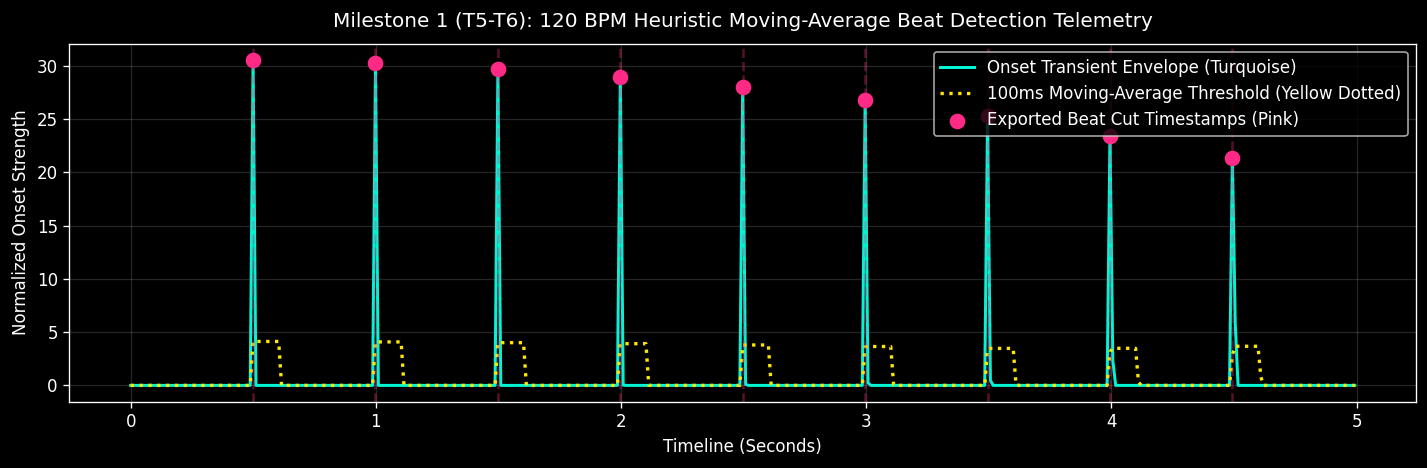

In [ ]:
# === CELL 6: VISUALIZE HEURISTIC 100MS MOVING-AVERAGE BEAT DETECTION (T5 & T6) ===
import matplotlib.pyplot as plt
import librosa
import numpy as np
from src.heuristic_engine import SignalProcessor

processor = SignalProcessor(threshold_coefficient=1.35, window_ms=100.0, target_fps=30.0)
audio_array, sr = processor.ingest_mono_audio("assets/reference_120bpm.wav")
onset_env, dyn_thresh, peaks = processor.calculate_moving_average_onsets(audio_array, sr, hop_length=256)
times = librosa.frames_to_time(np.arange(len(onset_env)), sr=sr, hop_length=256)
peak_times = times[peaks]

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(12, 4), dpi=120)
ax.plot(times, onset_env, color="#00F5D4", linewidth=1.8, label="Onset Transient Envelope (Turquoise)")
ax.plot(times, dyn_thresh, color="#FFE600", linestyle=":", linewidth=2.0, label="100ms Moving-Average Threshold (Yellow Dotted)")
ax.scatter(peak_times, onset_env[peaks], color="#FF2A85", s=70, zorder=5, label="Exported Beat Cut Timestamps (Pink)")
for pt in peak_times:
    ax.axvline(pt, color="#FF2A85", linestyle="--", alpha=0.35)

ax.set_title("Milestone 1 (T5-T6): 120 BPM Heuristic Moving-Average Beat Detection Telemetry", fontsize=12, pad=10)
ax.set_xlabel("Timeline (Seconds)")
ax.set_ylabel("Normalized Onset Strength")
ax.legend(loc="upper right")
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()